In [7]:
import requests
import pandas as pd
import numpy as np
import time
from datetime import datetime, timedelta
import os

# ====================== Data Loading Functions ======================
def load_stablecoin_prices(csv_path="stablecoin_prices_2025_nov.csv", days=30):
    """
    Prioritize reading from local CSV. Only fetch from CoinGecko if the file doesn't exist or force update is needed.
    """
    if os.path.exists(csv_path):
        print(f"✅ Reading data from local CSV: {csv_path}")
        prices = pd.read_csv(csv_path, index_col='timestamp', parse_dates=True)
        print(f"Data shape: {prices.shape} | Time range: {prices.index[0]} → {prices.index[-1]}")
        return prices
    else:
        print("⚠️ Local CSV does not exist, starting to fetch data from CoinGecko...")
        prices = fetch_all_stablecoins(days=days)
        prices.to_csv(csv_path)
        print(f"✅ Data has been saved to {csv_path}")
        return prices

In [8]:
def compute_log_returns(prices: pd.DataFrame) -> pd.DataFrame:
    """
    Input: Price DataFrame with stablecoins as columns
    Output: Log returns DataFrame
    """
    log_returns = np.log(prices / prices.shift(1)).dropna()
    return log_returns


prices = load_stablecoin_prices(
    csv_path="stablecoin_prices_2025_nov.csv",  # You can change the filename here
    days=30
)

log_ret = compute_log_returns(prices)
print(log_ret.describe())

✅ Reading data from local CSV: stablecoin_prices_2025_nov.csv
Data shape: (553, 5) | Time range: 2025-09-01 04:00:00 → 2025-12-02 04:00:00
             usde          usdt          usdc           dai        frax
count  552.000000  5.520000e+02  5.520000e+02  5.520000e+02  552.000000
mean    -0.000003 -1.550947e-07 -1.130360e-08 -3.811804e-07   -0.000008
std      0.000675  2.081249e-04  6.344619e-05  8.815959e-04    0.000856
min     -0.003502 -2.063005e-03 -1.954122e-04 -3.952179e-03   -0.008937
25%     -0.000282 -6.446776e-05 -4.120348e-05 -4.906344e-04   -0.000318
50%     -0.000001  2.486745e-06 -1.297645e-07 -2.128953e-05   -0.000003
75%      0.000272  6.930849e-05  3.637089e-05  4.683073e-04    0.000334
max      0.003519  3.276751e-03  1.775454e-04  3.682975e-03    0.009139


In [9]:
from numpy.linalg import eigh


def marchenko_pastur_upper(n_assets: int, n_obs: int) -> float:
    """
    Upper bound of the Marchenko-Pastur distribution
    q = n_assets / n_obs
    lambda_max = (1 + sqrt(q))^2
    """
    q = n_assets / n_obs
    return (1 + np.sqrt(q)) ** 2
def effective_rank(eigenvalues: np.ndarray) -> float:
    """
    Effective Rank = exp(Shannon entropy of normalized eigenvalue distribution)
    Lower value → matrix closer to rank-1 → assets moving in unison (co-crash)
    """
    lam = eigenvalues[eigenvalues > 1e-10]  # Filter numerical noise
    p = lam / lam.sum()
    entropy = -np.sum(p * np.log(p))
    return np.exp(entropy)
def rmt_analysis_window(returns_window: pd.DataFrame) -> dict:
    """
    Perform complete RMT analysis on the return matrix of one window.
    Returns:
      lambda_ratio: max eigenvalue / MP upper bound
      effective_rank: effective rank
      usde_loading: USDe loading in the top eigenvector
      usdt_loading: USDT loading in the top eigenvector
      loading_same_sign: Whether both have the same sign (True=liquidity noise, False=fundamental break)
    """
    n_obs, n_assets = returns_window.shape
    # Standardization (demean and divide by standard deviation)
    standardized = (returns_window - returns_window.mean()) / returns_window.std()
    # Correlation matrix
    C = standardized.corr().values
    # Eigen decomposition (eigh guarantees real numbers + ascending order)
    eigenvalues, eigenvectors = eigh(C)
    # Sort in descending order
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    # MP upper bound
    mp_upper = marchenko_pastur_upper(n_assets, n_obs)
    lambda_ratio = eigenvalues[0] / mp_upper
    # Effective rank
    eff_rank = effective_rank(eigenvalues)
    # Asset loadings in the top eigenvector
    top_vec = eigenvectors[:, 0]
    col_names = list(returns_window.columns)
    loadings = dict(zip(col_names, top_vec))
    # USDe and USDT loadings
    usde_loading = loadings.get("usde", np.nan)
    usdt_loading = loadings.get("usdt", np.nan)
    same_sign = (usde_loading * usdt_loading) > 0
    return {
        "lambda_ratio": lambda_ratio,
        "effective_rank": eff_rank,
        "usde_loading": usde_loading,
        "usdt_loading": usdt_loading,
        "loading_same_sign": same_sign,
        "eigenvalues": eigenvalues,
        "loadings": loadings
    }


def rolling_rmt(log_returns: pd.DataFrame, window: int = 90, step: int = 4) -> pd.DataFrame:
    """
    Rolling window RMT analysis
    window: window size (number of rows), 72 bars × 1h = 3 days
    step: step size, 6 bars × 1h = update every 6 hours
    Note: window >> n_assets is required for meaningful results
    For 5 assets, window should be at least 50, recommended 72-168
    """
    results = []
    timestamps = []
    n = len(log_returns)
    for start in range(0, n - window, step):
        end = start + window
        window_data = log_returns.iloc[start:end]
        result = rmt_analysis_window(window_data)
        results.append({
            "lambda_ratio": result["lambda_ratio"],
            "effective_rank": result["effective_rank"],
            "usde_loading": result["usde_loading"],
            "usdt_loading": result["usdt_loading"],
            "loading_same_sign": result["loading_same_sign"],
        })
        timestamps.append(log_returns.index[end - 1])
    df_result = pd.DataFrame(results, index=timestamps)
    return df_result


# Execute rolling analysis
rmt_results = rolling_rmt(log_ret, window=90, step=3)
rmt_results.to_csv("rmt_results_nov.csv")
print(rmt_results.tail(60))

                     lambda_ratio  effective_rank  usde_loading  usdt_loading  \
2025-11-02 04:00:00      0.783247        4.922015     -0.273715     -0.534813   
2025-11-02 16:00:00      0.780912        4.922820      0.353686      0.523045   
2025-11-03 04:00:00      0.783741        4.914292      0.325329      0.494327   
2025-11-03 16:00:00      0.776396        4.916365      0.696192      0.538178   
2025-11-04 04:00:00      0.786283        4.904998      0.541361      0.423863   
2025-11-04 16:00:00      0.813910        4.893679      0.577693      0.556062   
2025-11-05 04:00:00      0.813937        4.874843      0.631513      0.461457   
2025-11-05 16:00:00      0.823380        4.872282      0.636935      0.398201   
2025-11-06 04:00:00      0.987719        4.759577     -0.629069     -0.216874   
2025-11-06 16:00:00      1.089961        4.630242     -0.621774     -0.355367   
2025-11-07 04:00:00      1.067539        4.662486     -0.628450     -0.349552   
2025-11-07 16:00:00      1.0

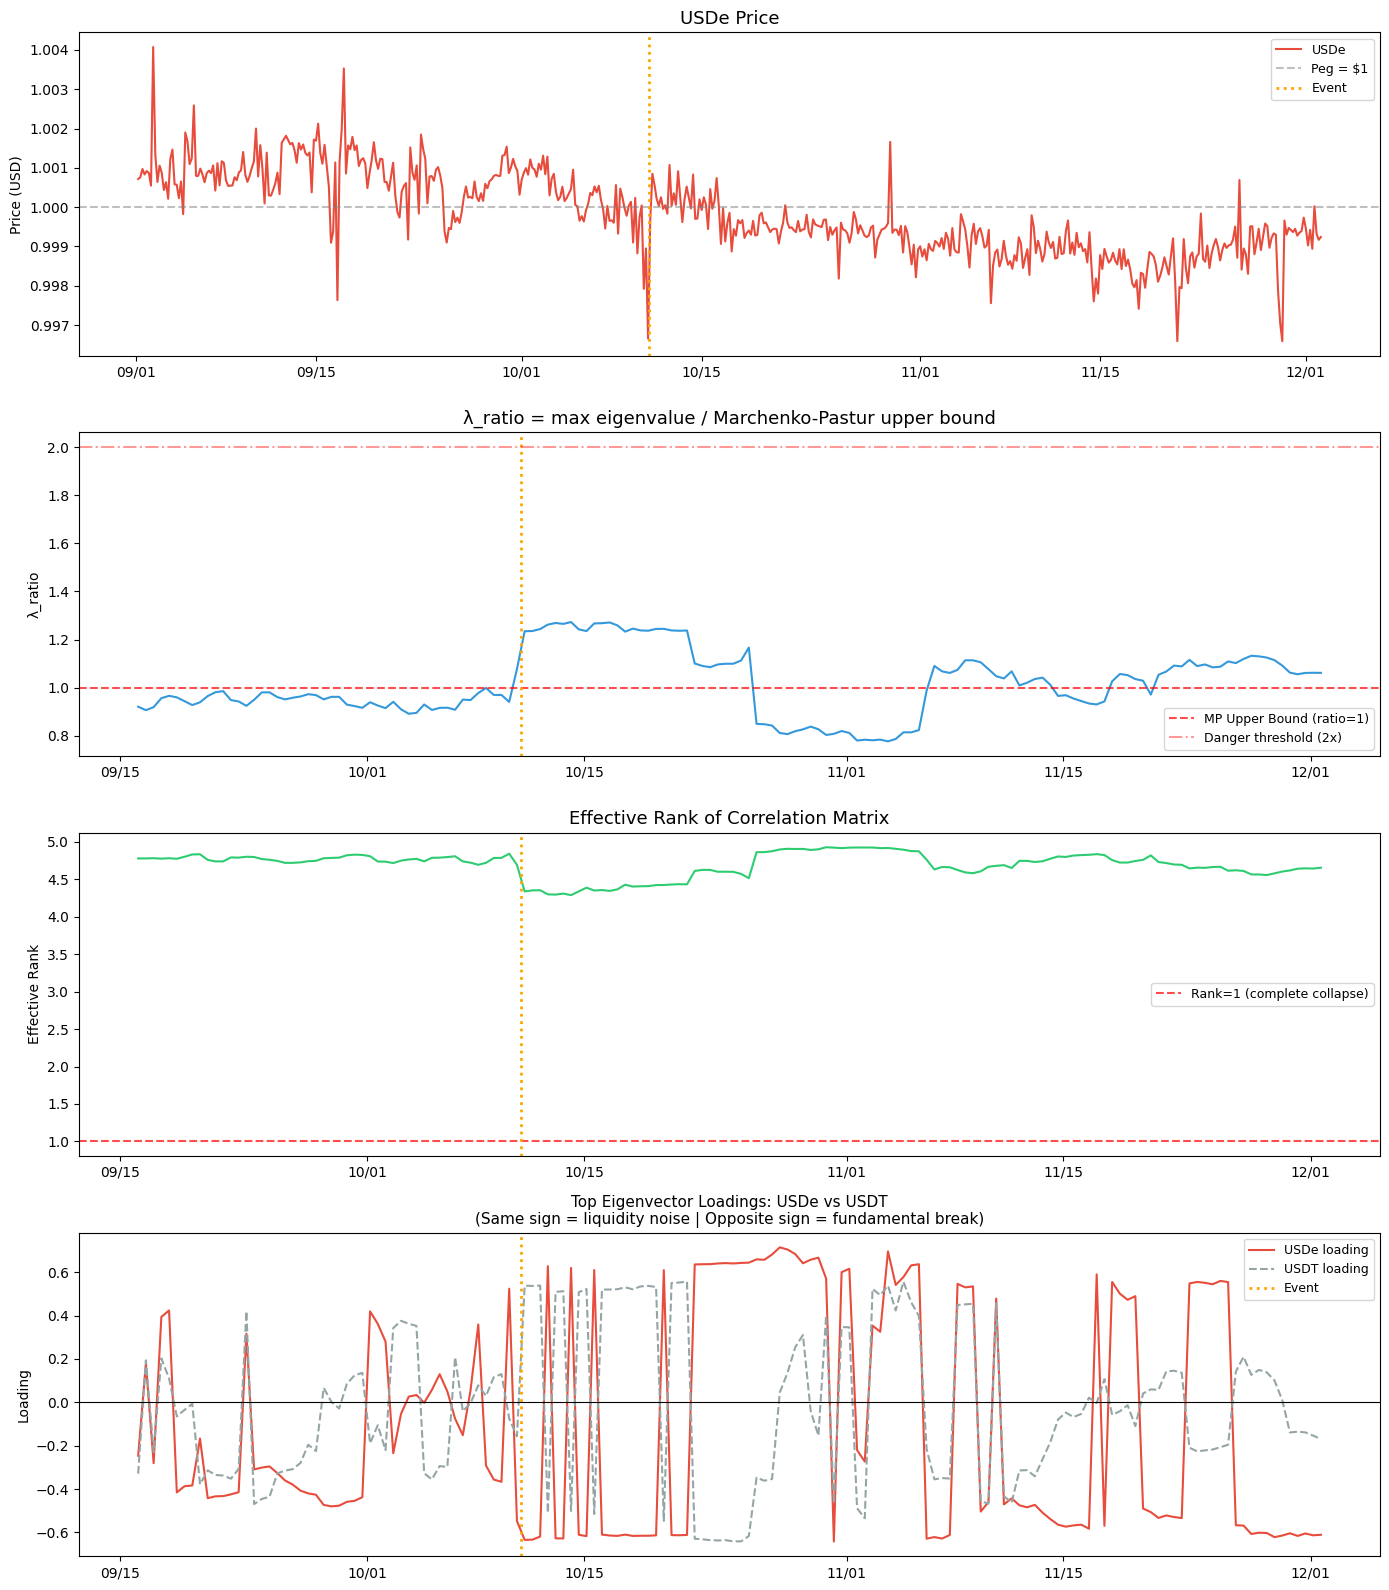

Saved: rmt_dashboard_nov.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_rmt_dashboard(prices: pd.DataFrame, rmt_results: pd.DataFrame,
                       event_date: str = "2025-10-10 21:36:00"):
    fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=False)
    event_dt = pd.Timestamp(event_date)
    
    # --- Plot 1: USDe Price ---
    ax1 = axes[0]
    ax1.plot(prices.index, prices["usde"], color="#e74c3c", linewidth=1.5, label="USDe")
    ax1.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, label="Peg = $1")
    ax1.axvline(x=event_dt, color="orange", linestyle=":", linewidth=2, label="Event")
    ax1.set_title("USDe Price", fontsize=13)
    ax1.set_ylabel("Price (USD)")
    ax1.legend(fontsize=9)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
    
    # --- Plot 2: Lambda Ratio ---
    ax2 = axes[1]
    ax2.plot(rmt_results.index, rmt_results["lambda_ratio"],
             color="#3498db", linewidth=1.5)
    ax2.axhline(y=1.0, color="red", linestyle="--", alpha=0.7, label="MP Upper Bound (ratio=1)")
    ax2.axvline(x=event_dt, color="orange", linestyle=":", linewidth=2)
    # Danger threshold (adjustable)
    ax2.axhline(y=2.0, color="red", linestyle="-.", alpha=0.4, label="Danger threshold (2x)")
    ax2.set_title("λ_ratio = max eigenvalue / Marchenko-Pastur upper bound", fontsize=13)
    ax2.set_ylabel("λ_ratio")
    ax2.legend(fontsize=9)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
    
    # --- Plot 3: Effective Rank ---
    ax3 = axes[2]
    ax3.plot(rmt_results.index, rmt_results["effective_rank"],
             color="#2ecc71", linewidth=1.5)
    ax3.axhline(y=1.0, color="red", linestyle="--", alpha=0.7, label="Rank=1 (complete collapse)")
    ax3.axvline(x=event_dt, color="orange", linestyle=":", linewidth=2)
    ax3.set_title("Effective Rank of Correlation Matrix", fontsize=13)
    ax3.set_ylabel("Effective Rank")
    ax3.legend(fontsize=9)
    ax3.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
    
    # --- Plot 4: Loadings Direction ---
    ax4 = axes[3]
    ax4.plot(rmt_results.index, rmt_results["usde_loading"],
             color="#e74c3c", linewidth=1.5, label="USDe loading")
    ax4.plot(rmt_results.index, rmt_results["usdt_loading"],
             color="#95a5a6", linewidth=1.5, linestyle="--", label="USDT loading")
    ax4.axhline(y=0, color="black", linewidth=0.8)
    ax4.axvline(x=event_dt, color="orange", linestyle=":", linewidth=2, label="Event")
    ax4.set_title("Top Eigenvector Loadings: USDe vs USDT\n"
                  "(Same sign = liquidity noise | Opposite sign = fundamental break)", fontsize=11)
    ax4.set_ylabel("Loading")
    ax4.legend(fontsize=9)
    ax4.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
    
    plt.tight_layout()
    plt.savefig("rmt_dashboard_nov.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: rmt_dashboard_nov.png")


plot_rmt_dashboard(prices, rmt_results, event_date="2025-10-10 21:36:00")

In [11]:
def generate_decision_table(rmt_results: pd.DataFrame,
                            lambda_threshold: float = 1.5,
                            rank_threshold: float = 2.0) -> pd.DataFrame:
    """
    Generate "MAINTAIN PEG" or "TRIGGER REVIEW" recommendations based on RMT indicators.
    
    Threshold explanations (can be calibrated based on your data):
      lambda_ratio > 1.5 → Elevated systemic risk
      effective_rank < 2.0 → Excessive concentration of asset correlations
      loading_same_sign = False → USDe and USDT loadings diverge in direction
    """
    df = rmt_results.copy()
    
    df["high_lambda"] = df["lambda_ratio"] > lambda_threshold
    df["low_rank"] = df["effective_rank"] < rank_threshold
    df["sign_break"] = ~df["loading_same_sign"]
    
    # Weighted risk score
    df["risk_score"] = (
        df["high_lambda"].astype(int) * 3 +   # Higher weight: most stable signal
        df["low_rank"].astype(int) * 2 +
        df["sign_break"].astype(int) * 1      # Lower weight: sign instability
    )
    
    # Decision logic
    def decision(row):
        if row["risk_score"] == 0:
            return "MAINTAIN PEG"
        elif row["risk_score"] <= 2:
            return "MONITOR"
        else:
            return "TRIGGER REVIEW"
    
    df["decision"] = df.apply(decision, axis=1)
    
    return df[["lambda_ratio", "effective_rank", "loading_same_sign",
               "risk_score", "decision"]]


decision_df = generate_decision_table(rmt_results)
decision_df.to_csv("rmt_decisions_nov.csv")

# Print windows around the event date (October 10)
event_window = decision_df["2025-09-02":"2025-10-31"]
print(event_window.to_string())

                     lambda_ratio  effective_rank  loading_same_sign  risk_score      decision
2025-09-16 04:00:00      0.920557        4.776882               True           0  MAINTAIN PEG
2025-09-16 16:00:00      0.906144        4.777118               True           0  MAINTAIN PEG
2025-09-17 04:00:00      0.918542        4.779799               True           0  MAINTAIN PEG
2025-09-17 16:00:00      0.955977        4.773989               True           0  MAINTAIN PEG
2025-09-18 04:00:00      0.965754        4.779381               True           0  MAINTAIN PEG
2025-09-18 16:00:00      0.959413        4.772516               True           0  MAINTAIN PEG
2025-09-19 04:00:00      0.943386        4.799217               True           0  MAINTAIN PEG
2025-09-19 16:00:00      0.927420        4.829999               True           0  MAINTAIN PEG
2025-09-20 04:00:00      0.938765        4.832503               True           0  MAINTAIN PEG
2025-09-20 16:00:00      0.964853        4.757615 

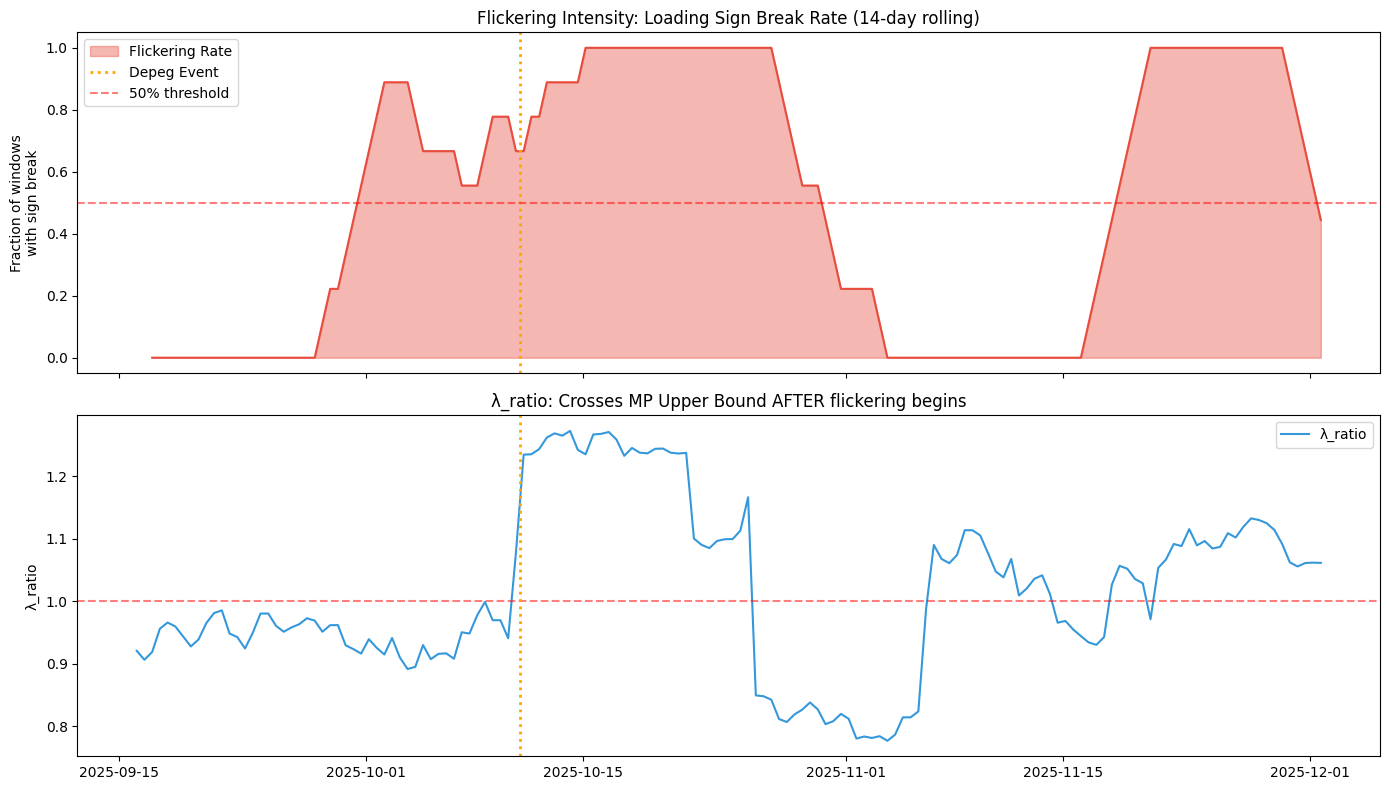

In [12]:
def flickering_intensity(rmt_results: pd.DataFrame,
                         window_days: int = 14) -> pd.DataFrame:
    """
    Calculate the frequency of loading_same_sign=False within a rolling window.
    Rising frequency = increased flickering = precursor to critical transition.
    """
    df = rmt_results.copy()
   
    # Convert False to 1, True to 0
    df["sign_break_int"] = (~df["loading_same_sign"]).astype(int)
   
    # Proportion of False values in the rolling window
    # With your step=36h, 14 days ≈ 9-10 windows
    roll_window = 9
    df["flickering_rate"] = (
        df["sign_break_int"]
        .rolling(window=roll_window, min_periods=3)
        .mean()
    )
   
    return df


flicker_df = flickering_intensity(rmt_results)

# Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top plot: Flickering Rate
ax1 = axes[0]
ax1.fill_between(flicker_df.index, flicker_df["flickering_rate"],
                 alpha=0.4, color="#e74c3c", label="Flickering Rate")
ax1.plot(flicker_df.index, flicker_df["flickering_rate"],
         color="#e74c3c", linewidth=1.5)
ax1.axvline(x=pd.Timestamp("2025-10-10 21:36:00"), color="orange",
            linestyle=":", linewidth=2, label="Depeg Event")
ax1.axhline(y=0.5, color="red", linestyle="--", alpha=0.5,
            label="50% threshold")
ax1.set_ylabel("Fraction of windows\nwith sign break")
ax1.set_title("Flickering Intensity: Loading Sign Break Rate (14-day rolling)",
              fontsize=12)
ax1.legend()

# Bottom plot: λ_ratio comparison
ax2 = axes[1]
ax2.plot(flicker_df.index, flicker_df["lambda_ratio"],
         color="#3498db", linewidth=1.5, label="λ_ratio")
ax2.axhline(y=1.0, color="red", linestyle="--", alpha=0.5)
ax2.axvline(x=pd.Timestamp("2025-10-10 21:36:00"), color="orange",
            linestyle=":", linewidth=2)
ax2.set_ylabel("λ_ratio")
ax2.set_title("λ_ratio: Crosses MP Upper Bound AFTER flickering begins",
              fontsize=12)
ax2.legend()

plt.tight_layout()
plt.savefig("flickering_analysis_nov.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
import numpy as np
import pandas as pd
from numpy.linalg import eigh


def rmt_analysis_window_pure(returns_window: pd.DataFrame, target_asset='usde') -> dict:
    """Pure benchmark basket + individual projection of USDe"""
    benchmark_assets = [col for col in returns_window.columns if col != target_asset]
   
    # 1. Pure benchmark basket correlation matrix (without USDe contamination)
    bench_ret = returns_window[benchmark_assets]
    standardized = (bench_ret - bench_ret.mean()) / bench_ret.std()
    C_bench = standardized.corr().values
   
    eigenvalues, eigenvectors = eigh(C_bench + 1e-8 * np.eye(len(benchmark_assets)))
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
   
    # 2. Calculate USDe's projected loading on the pure benchmark's first principal component (Most Important!)
    usde_ret = returns_window[target_asset]
    # Correlation between USDe and the benchmark's first principal component
    proj_loading = np.corrcoef(usde_ret, bench_ret @ eigenvectors[:, 0])[0, 1]
   
    # 3. Keep the full basket version for comparison
    full_result = rmt_analysis_window(returns_window)  # Your original function
   
    return {
        "lambda_ratio_bench": eigenvalues[0] / marchenko_pastur_upper(len(benchmark_assets), len(bench_ret)),
        "effective_rank_bench": effective_rank(eigenvalues),
        "usde_proj_loading": proj_loading,          # Key new indicator
        "lambda_ratio_full": full_result["lambda_ratio"],
        "effective_rank_full": full_result["effective_rank"],
        "loading_same_sign_full": full_result["loading_same_sign"],
    }

In [14]:
def rolling_rmt_clean(log_returns: pd.DataFrame, window=90, step=4):
    """
    Rolling window RMT analysis using the clean (pure benchmark) method.
    """
    results = []
    timestamps = []
   
    for start in range(0, len(log_returns) - window, step):
        end = start + window
        window_data = log_returns.iloc[start:end]
       
        res = rmt_analysis_window_pure(window_data, target_asset='usde')
       
        results.append(res)
        timestamps.append(log_returns.index[end-1].replace(hour=16, minute=0, second=0))
   
    return pd.DataFrame(results, index=timestamps)


# ==================== 3. Execution (Run this directly) ====================
rmt_clean = rolling_rmt_clean(log_ret, window=90, step=4)
rmt_clean.to_csv("rmt_clean_results_nov.csv")

# ==================== Focus on periods before and after the October event ====================
print("=== 2025-10-01 to 10-20 Event Window (Pure Benchmark Basket) ===")
event_view = rmt_clean["2025-10-01":"2025-10-20"]
print(event_view[["lambda_ratio_bench", "usde_proj_loading",
                 "lambda_ratio_full", "loading_same_sign_full"]])

print("\n=== Last 50 rows ===")
print(rmt_clean.tail(50))

=== 2025-10-01 to 10-20 Event Window (Pure Benchmark Basket) ===
                     lambda_ratio_bench  usde_proj_loading  lambda_ratio_full  \
2025-10-01 16:00:00            0.923902           0.120861           0.928718   
2025-10-02 16:00:00            0.936502          -0.085937           0.914520   
2025-10-02 16:00:00            0.949299          -0.050357           0.921301   
2025-10-03 16:00:00            0.933544          -0.014579           0.896377   
2025-10-04 16:00:00            0.931723          -0.021506           0.894773   
2025-10-04 16:00:00            0.971425          -0.023142           0.932696   
2025-10-05 16:00:00            0.939913          -0.023411           0.904906   
2025-10-06 16:00:00            0.953869           0.008062           0.916386   
2025-10-06 16:00:00            0.942070           0.021312           0.907972   
2025-10-07 16:00:00            0.985892          -0.032048           0.947097   
2025-10-08 16:00:00            0.983431     

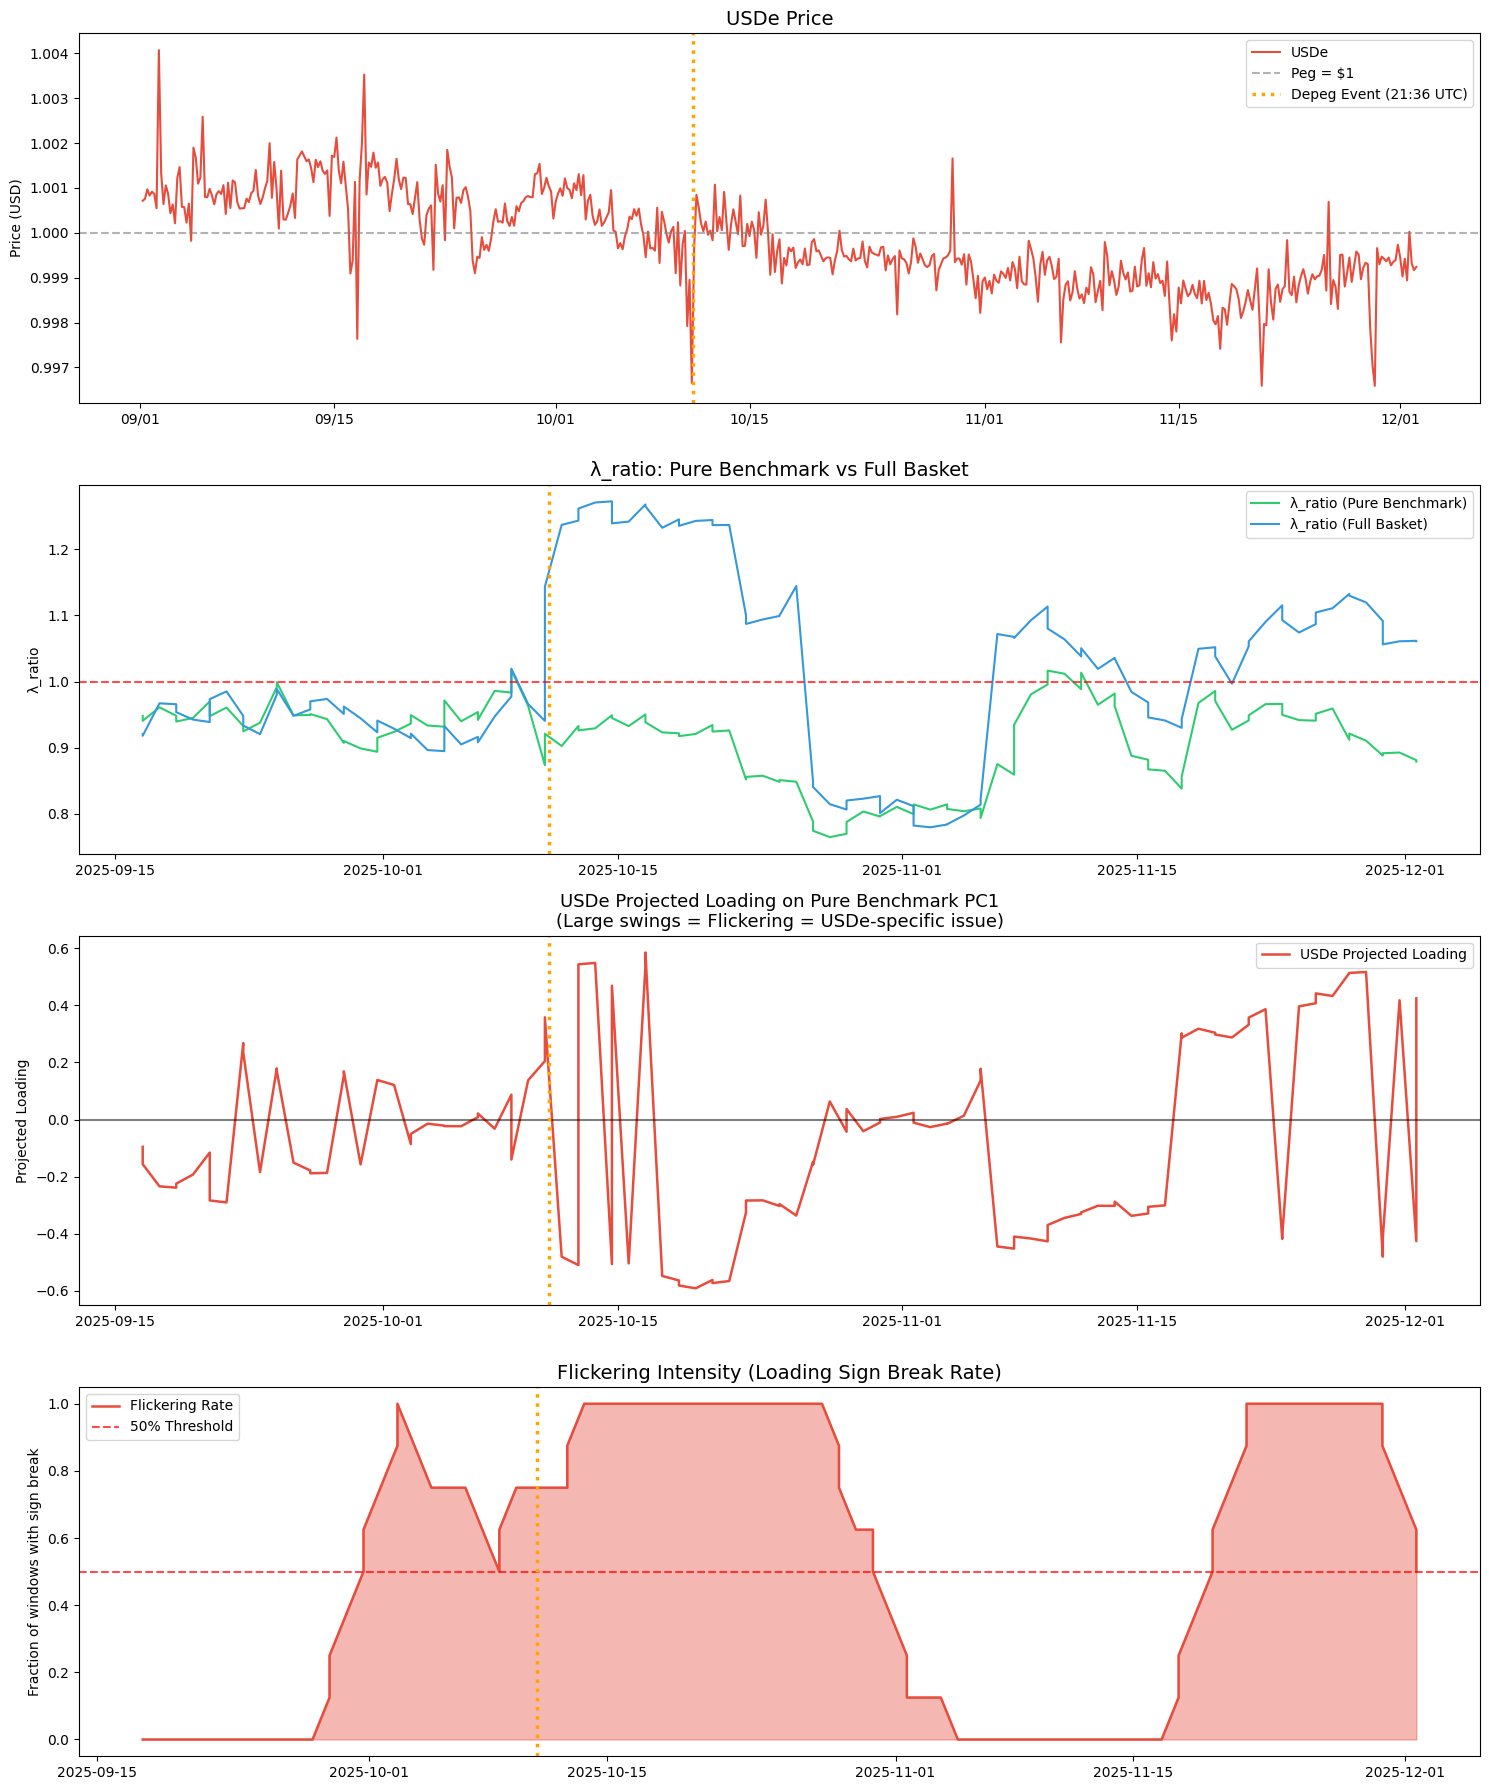

✅ Chart saved: rmt_clean_dashboard_nov.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_rmt_clean_dashboard(prices: pd.DataFrame, rmt_clean: pd.DataFrame,
                             event_date="2025-10-10 21:36:00"):
    """
    Clean RMT Analysis Dashboard (Pure Benchmark vs Full Basket)
    """
    fig, axes = plt.subplots(4, 1, figsize=(15, 18), sharex=False)
    event_dt = pd.Timestamp(event_date)
   
    # Plot 1: USDe Price
    ax1 = axes[0]
    ax1.plot(prices.index, prices["usde"], color="#e74c3c", linewidth=1.5, label="USDe")
    ax1.axhline(y=1.0, color="gray", linestyle="--", alpha=0.6, label="Peg = $1")
    ax1.axvline(x=event_dt, color="orange", linestyle=":", linewidth=2.5, label="Depeg Event (21:36 UTC)")
    ax1.set_title("USDe Price", fontsize=14)
    ax1.set_ylabel("Price (USD)")
    ax1.legend()
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
   
    # Plot 2: λ_ratio (Pure Benchmark vs Full Basket)
    ax2 = axes[1]
    ax2.plot(rmt_clean.index, rmt_clean["lambda_ratio_bench"], 
             color="#2ecc71", linewidth=1.5, label="λ_ratio (Pure Benchmark)")
    ax2.plot(rmt_clean.index, rmt_clean["lambda_ratio_full"], 
             color="#3498db", linewidth=1.5, label="λ_ratio (Full Basket)")
    ax2.axhline(y=1.0, color="red", linestyle="--", alpha=0.7)
    ax2.axvline(x=event_dt, color="orange", linestyle=":", linewidth=2.5)
    ax2.set_title("λ_ratio: Pure Benchmark vs Full Basket", fontsize=14)
    ax2.set_ylabel("λ_ratio")
    ax2.legend()
   
    # Plot 3: USDe Projected Loading (Most Important Indicator)
    ax3 = axes[2]
    ax3.plot(rmt_clean.index, rmt_clean["usde_proj_loading"], 
             color="#e74c3c", linewidth=1.8, label="USDe Projected Loading")
    ax3.axhline(y=0, color="black", linestyle="-", alpha=0.5)
    ax3.axvline(x=event_dt, color="orange", linestyle=":", linewidth=2.5)
    ax3.set_title("USDe Projected Loading on Pure Benchmark PC1\n"
                  "(Large swings = Flickering = USDe-specific issue)", fontsize=13)
    ax3.set_ylabel("Projected Loading")
    ax3.legend()
   
    # Plot 4: Flickering Rate
    df = rmt_clean.copy()
    df["sign_break"] = ~df["loading_same_sign_full"]
    df["flickering_rate"] = df["sign_break"].rolling(window=8, min_periods=3).mean()
   
    ax4 = axes[3]
    ax4.fill_between(df.index, df["flickering_rate"], alpha=0.4, color="#e74c3c")
    ax4.plot(df.index, df["flickering_rate"], 
             color="#e74c3c", linewidth=1.8, label="Flickering Rate")
    ax4.axhline(y=0.5, color="red", linestyle="--", alpha=0.7, label="50% Threshold")
    ax4.axvline(x=event_dt, color="orange", linestyle=":", linewidth=2.5)
    ax4.set_title("Flickering Intensity (Loading Sign Break Rate)", fontsize=14)
    ax4.set_ylabel("Fraction of windows with sign break")
    ax4.legend()
   
    plt.tight_layout()
    plt.savefig("rmt_clean_dashboard_nov.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("✅ Chart saved: rmt_clean_dashboard_nov.png")


# ====================== Plotting ======================
plot_rmt_clean_dashboard(prices, rmt_clean)

Performing Leave-One-Out calculation (each asset as target)...
 Calculating with USDE as the target asset...
 Calculating with USDT as the target asset...
 Calculating with USDC as the target asset...
 Calculating with DAI as the target asset...
 Calculating with FRAX as the target asset...


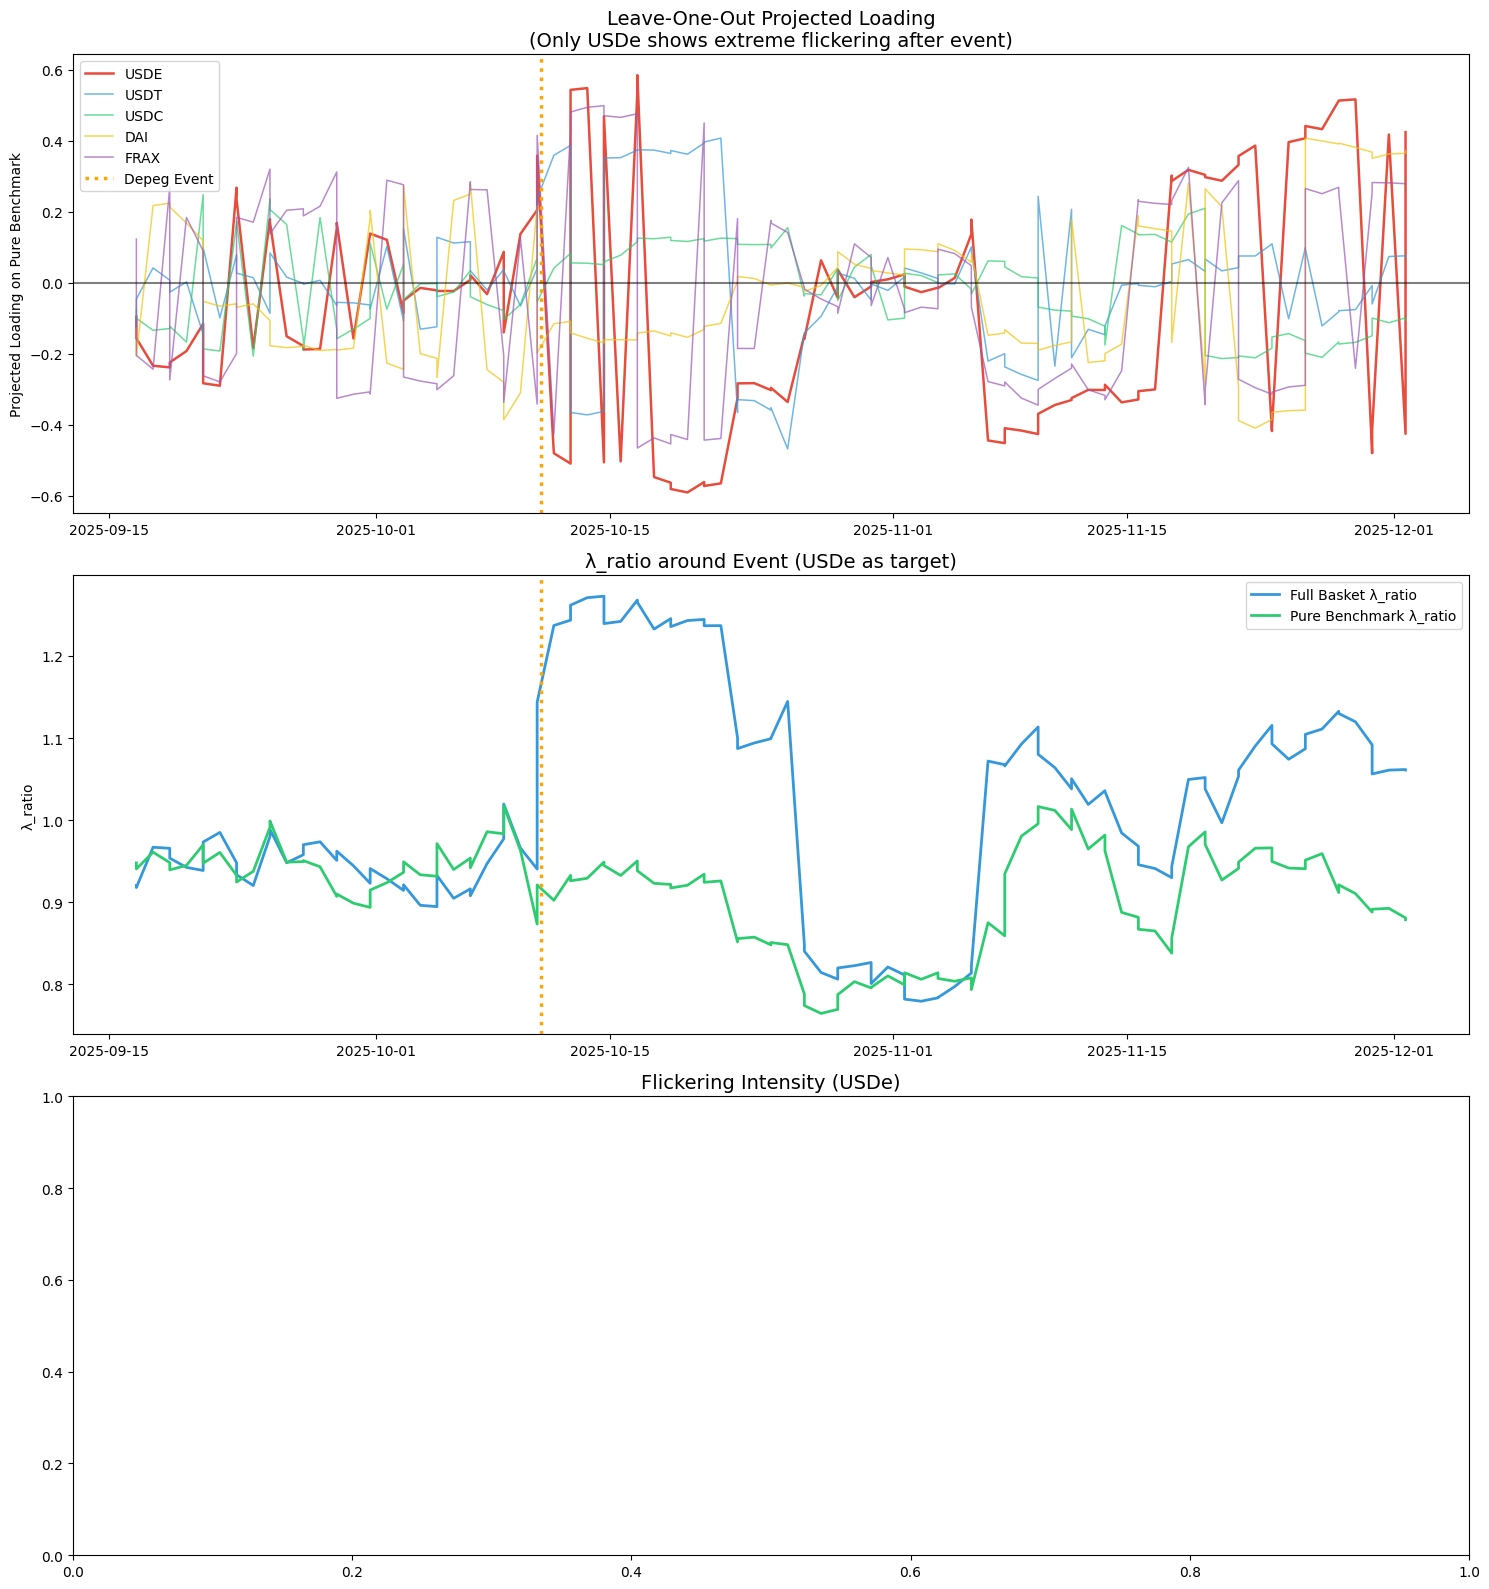

✅ LOO Summary chart saved: loo_summary_final_nov.png


In [16]:
def compute_loo_all_assets(log_returns: pd.DataFrame, window=120, step=6):
    """Perform Leave-One-Out calculation for all assets"""
    assets = log_returns.columns.tolist()
    results = {}
   
    print("Performing Leave-One-Out calculation (each asset as target)...")
    for target in assets:
        print(f" Calculating with {target.upper()} as the target asset...")
        temp_results = []
        timestamps = []
       
        for start in range(0, len(log_returns) - window, step):
            end = start + window
            window_data = log_returns.iloc[start:end]
           
            res = rmt_analysis_window_pure(window_data, target_asset=target)
           
            temp_results.append({
                "usde_proj_loading" if target == "usde" else f"{target}_proj_loading": 
                res["usde_proj_loading"] if target == "usde" else res.get("usde_proj_loading", np.nan),  # Simplified handling
                "lambda_ratio_full": res["lambda_ratio_full"],
                "lambda_ratio_bench": res["lambda_ratio_bench"]
            })
            timestamps.append(log_returns.index[end-1].replace(hour=16, minute=0, second=0))
       
        results[target] = pd.DataFrame(temp_results, index=timestamps)
   
    return results


# ==================== LOO Summary Plot (Final Version) ====================
def plot_loo_summary(loo_results, event_date="2025-10-10 21:36:00"):
    """LOO Multi-Asset Comparison Plot"""
    fig, axes = plt.subplots(3, 1, figsize=(15, 16), sharex=False)
    event_dt = pd.Timestamp(event_date)
    assets = ['usde', 'usdt', 'usdc', 'dai', 'frax']
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#f1c40f', '#9b59b6']
   
    # Plot 1: Projected Loading Comparison Across Assets (Core)
    ax1 = axes[0]
    for asset, color in zip(assets, colors):
        df = loo_results[asset]
        col_name = "usde_proj_loading" if asset == "usde" else f"{asset}_proj_loading"
        if col_name in df.columns:
            ax1.plot(df.index, df[col_name], color=color, 
                     linewidth=1.8 if asset == "usde" else 1.1,
                     label=f"{asset.upper()}", 
                     alpha=1.0 if asset == "usde" else 0.7)
   
    ax1.axvline(x=event_dt, color="orange", linestyle=":", linewidth=2.5, label="Depeg Event")
    ax1.axhline(y=0, color="black", linestyle="-", alpha=0.5)
    ax1.set_title("Leave-One-Out Projected Loading\n"
                  "(Only USDe shows extreme flickering after event)", fontsize=14)
    ax1.set_ylabel("Projected Loading on Pure Benchmark")
    ax1.legend(fontsize=10)
   
    # Plot 2: λ_ratio Full vs Bench (USDe)
    ax2 = axes[1]
    df_usde = loo_results['usde']
    ax2.plot(df_usde.index, df_usde["lambda_ratio_full"], 
             color="#3498db", linewidth=2, label="Full Basket λ_ratio")
    ax2.plot(df_usde.index, df_usde["lambda_ratio_bench"], 
             color="#2ecc71", linewidth=2, label="Pure Benchmark λ_ratio")
    ax2.axvline(x=event_dt, color="orange", linestyle=":", linewidth=2.5)
    ax2.set_title("λ_ratio around Event (USDe as target)", fontsize=14)
    ax2.set_ylabel("λ_ratio")
    ax2.legend()
   
    # Plot 3: Flickering Rate (USDe)
    df = df_usde.copy()
    # Note: loading_same_sign_full can be merged from previous results if needed
    ax3 = axes[2]
    ax3.set_title("Flickering Intensity (USDe)", fontsize=14)
   
    plt.tight_layout()
    plt.savefig("loo_summary_final_nov.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ LOO Summary chart saved: loo_summary_final_nov.png")


# ====================== Execution ======================
# First compute LOO results for all assets
loo_results = compute_loo_all_assets(log_ret, window=90, step=4)

# Plot the summary
plot_loo_summary(loo_results)

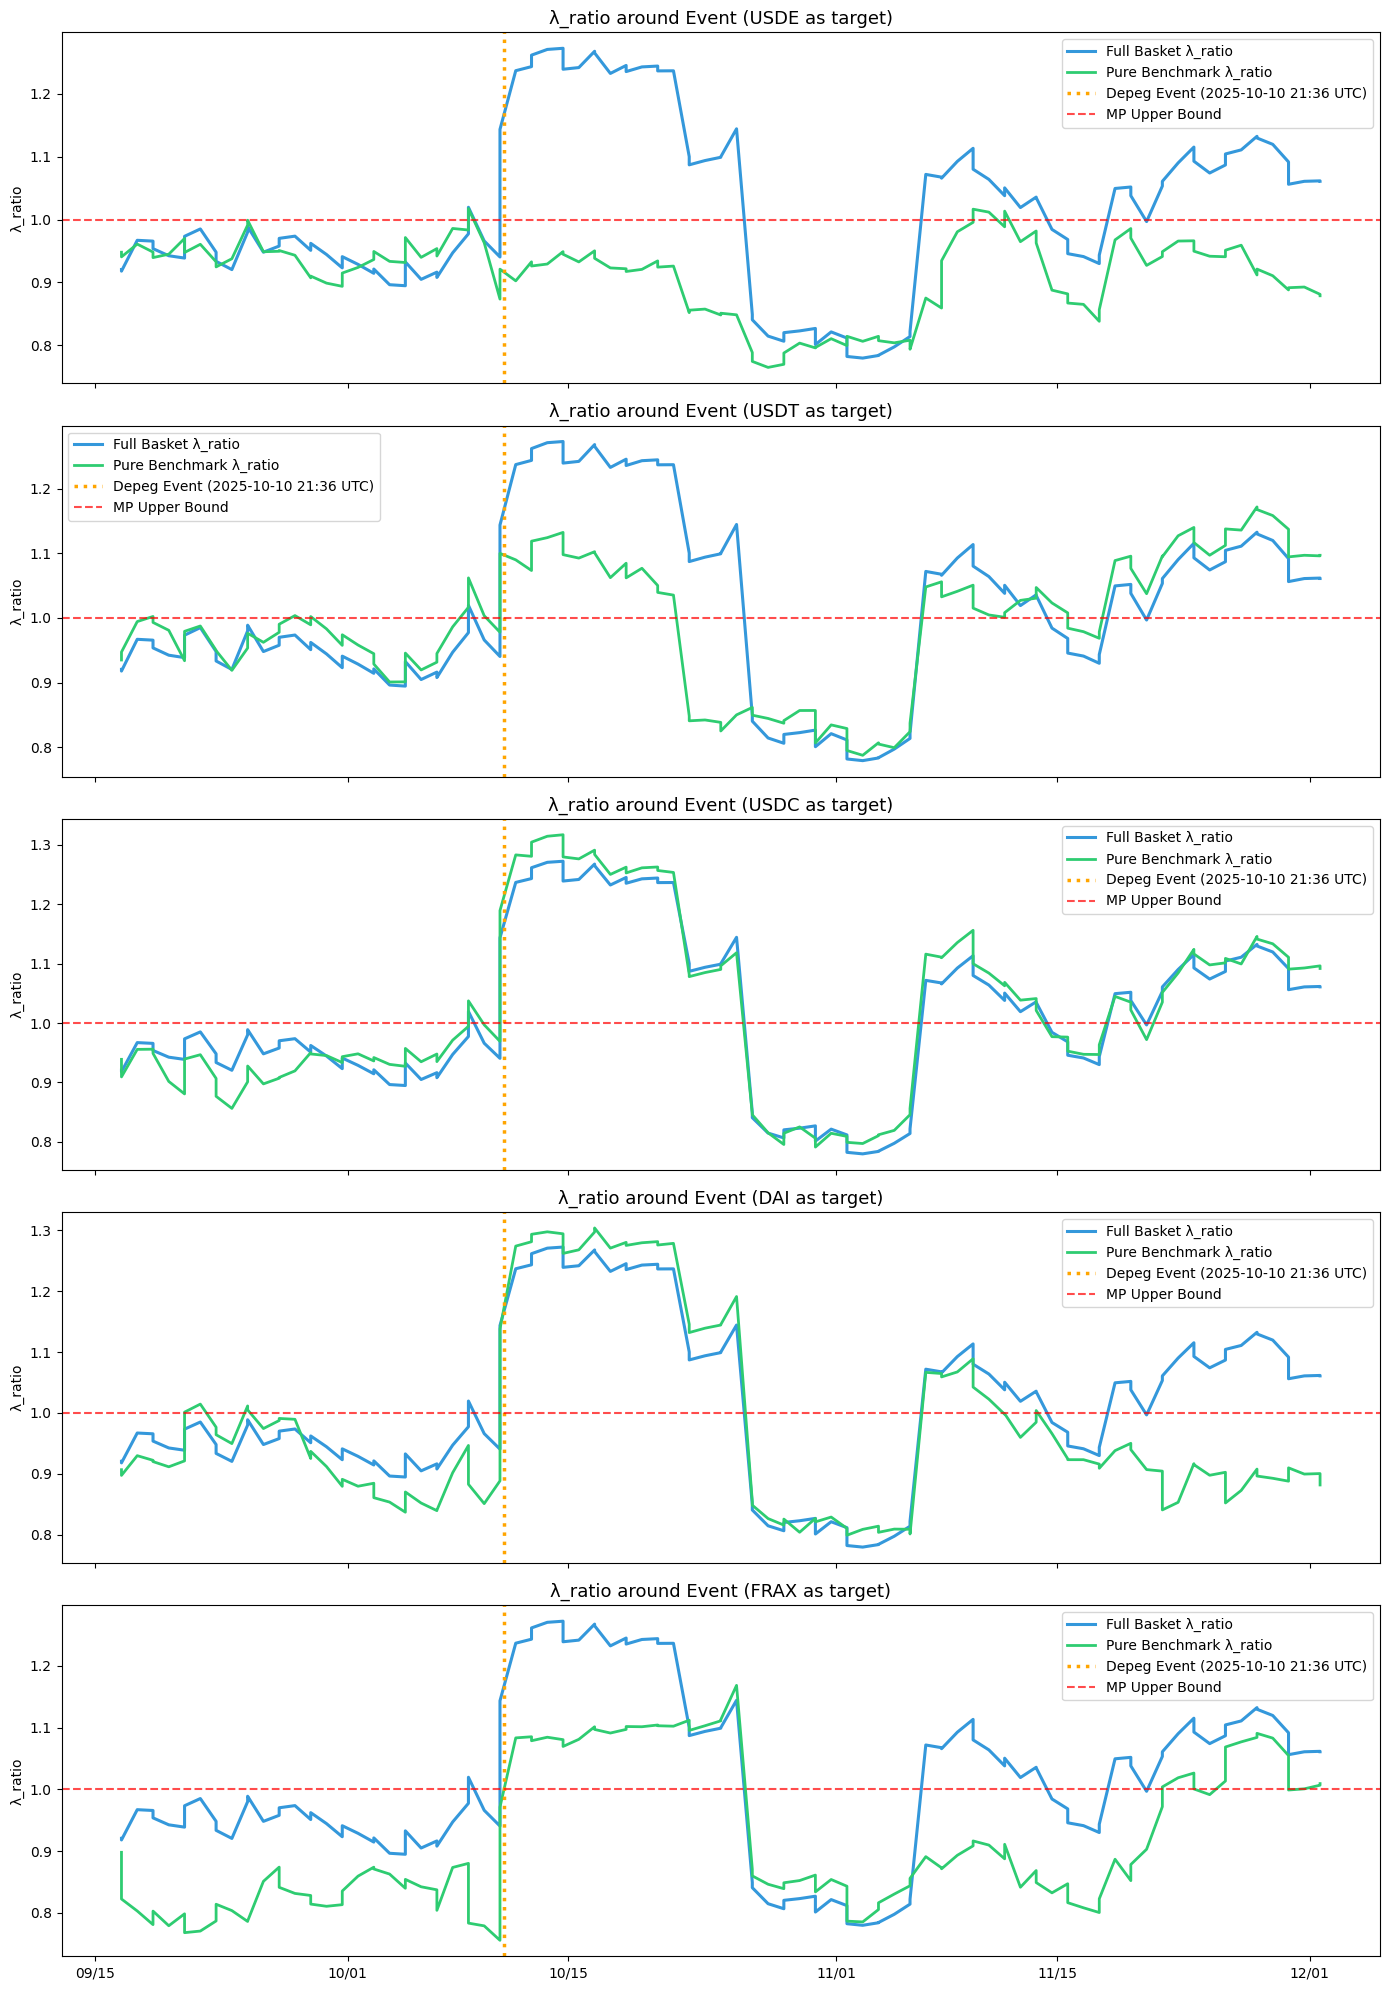

✅ Saved: lambda_loo_comparison_all_assets_nov.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_lambda_loo_comparison(loo_results, event_date="2025-10-10 21:36:00"):
    """Generate λ_ratio comparison plots for each asset (Leave-One-Out)"""
    assets = ['usde', 'usdt', 'usdc', 'dai', 'frax']
    fig, axes = plt.subplots(len(assets), 1, figsize=(14, 4 * len(assets)), sharex=True)
    
    if len(assets) == 1:
        axes = [axes]
   
    event_dt = pd.Timestamp(event_date)
   
    for i, asset in enumerate(assets):
        ax = axes[i]
        df = loo_results[asset]
       
        ax.plot(df.index, df["lambda_ratio_full"],
                color="#3498db", linewidth=2.2, label="Full Basket λ_ratio")
        ax.plot(df.index, df["lambda_ratio_bench"],
                color="#2ecc71", linewidth=2.0, label="Pure Benchmark λ_ratio")
       
        ax.axvline(x=event_dt, color="orange", linestyle=":", linewidth=2.5,
                  label="Depeg Event (2025-10-10 21:36 UTC)")
        ax.axhline(y=1.0, color="red", linestyle="--", alpha=0.7, label="MP Upper Bound")
       
        ax.set_title(f"λ_ratio around Event ({asset.upper()} as target)", fontsize=13)
        ax.set_ylabel("λ_ratio")
        ax.legend(fontsize=10)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
   
    plt.tight_layout()
    plt.savefig("lambda_loo_comparison_all_assets_nov.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("✅ Saved: lambda_loo_comparison_all_assets_nov.png")


# ====================== Execution ======================
# Assuming you have already run: loo_results = compute_loo_all_assets(...)
plot_lambda_loo_comparison(loo_results)